# 工业企业财务数据

## 1 初识工业企业财务数据

利润表|资产负债表
-|-
营业收入|货币资金
-营业成本|应收账款
**毛利**|存货
-营业税金及附加|其它流动资产
-销售费用|**流动资产**
-管理费用|固定资产
-财务费用|无形资产
-资产减值损失|其他非流动性资产
+公允价值变动收益|**总资产**
+投资收益|流动负债
**营业利润**|非流动负债
+营业外收入|**总负债**
-营业外支出|**所有者权益**
**利润总额**
-所得税
**净利润**

## 2 工业企业利润表解读

### 2.1 工业企业利润表结构分析

统计局按月公布工业企业的营业收入、利润总额，比a股上市公司的季报时效性更高。

2019年后主营业务收入（成本）被营业收入（成本）替代，因为两者差距比较小，可以直接衔接起来。

股票价格 = 市盈率（PE）*每股收益（EPS）

如果把利润总额增速近似看成EPS增速，那么分析工业企业利润增速可以帮助我们对股票定价。

In [1]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re
import math

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

figsize = (15,5)

In [2]:
industryFinancialDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="工业>工业企业主要经济指标", period="2011-"
)
industryFinancialDf = industryFinancialDf.transpose().iloc[::-1]

In [3]:
ppiDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="价格指数>工业生产者出厂价格分类指数>工业生产者出厂价格指数(上年同期=100)",
    period="2011-",
)
ppiDf = ppiDf.transpose().iloc[::-1]

In [4]:
gyzjzDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="工业>工业增加值增长速度", period="2011-"
)
gyzjzDf = gyzjzDf.transpose().iloc[::-1]

In [5]:
profitByCategoriesDf1 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业利润总额",
    period="2018",
)
profitByCategoriesDf2 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业利润总额",
    period="2019-",
)
profitByCategoriesDf = pd.concat([profitByCategoriesDf2, profitByCategoriesDf1], axis=1)
profitByCategoriesDf = profitByCategoriesDf.transpose().iloc[::-1]

In [6]:
gyqyEconomicDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按登记注册类型分工业企业主要经济指标（-2023）>国有工业企业主要经济指标",
    period="2011-",
)
gyqyEconomicDf = gyqyEconomicDf.transpose().iloc[::-1]

In [7]:
srqyEconomicDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按登记注册类型分工业企业主要经济指标（-2023）>私营工业企业主要经济指标",
    period="2011-",
)
srqyEconomicDf = srqyEconomicDf.transpose().iloc[::-1]

In [8]:
# 按行业分工业企业营业收入
yysrByCatetoriesDf1 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2003-2011)>工业企业主营业务收入",
    period="2003-2011",
)
yysrByCatetoriesDf2 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2012-2017)>工业企业主营业务收入",
    period="2012-2017",
)
# 一次查全部报错，分开查
yysrByCatetoriesDf3 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业营业收入",
    period="2018",
)
yysrByCatetoriesDf4 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业营业收入",
    period="2019-",
)

# 按行业分工业企业成品存货
ccpchByCatetoriesDf1 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2003-2011)>工业企业产成品存货",
    period="2003-2011",
)
ccpchByCatetoriesDf2 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2012-2017)>工业企业产成品存货",
    period="2012-2017",
)
# 一次查全部报错，分开查
ccpchByCatetoriesDf3 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业产成品存货",
    period="2018",
)
ccpchByCatetoriesDf4 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业产成品存货",
    period="2019-",
)

In [9]:
yysrByCatetoriesDf1.shape, yysrByCatetoriesDf2.shape, yysrByCatetoriesDf3.shape, yysrByCatetoriesDf4.shape
# yysrByCatetoriesDf = pd.concat([
#     yysrByCatetoriesDf1.transpose().iloc[::-1],
#     yysrByCatetoriesDf2.transpose().iloc[::-1],
#     # yysrByCatetoriesDf3.transpose().iloc[::-1],
#     # yysrByCatetoriesDf4.transpose().iloc[::-1],
# ])
columns1 = yysrByCatetoriesDf1.index
columns2 = yysrByCatetoriesDf2.index
for name in columns2:
    if name not in columns1:
        print(name)

开采辅助活动主营业务收入_累计值(亿元)
开采辅助活动主营业务收入_上年同期累计值(亿元)
开采辅助活动主营业务收入_累计增长(%)
酒、饮料和精制茶制造业主营业务收入_累计值(亿元)
酒、饮料和精制茶制造业主营业务收入_上年同期累计值(亿元)
酒、饮料和精制茶制造业主营业务收入_累计增长(%)
纺织服装、服饰业主营业务收入_累计值(亿元)
纺织服装、服饰业主营业务收入_上年同期累计值(亿元)
纺织服装、服饰业主营业务收入_累计增长(%)
皮革、毛皮、羽毛及其制品和制鞋业主营业务收入_累计值(亿元)
皮革、毛皮、羽毛及其制品和制鞋业主营业务收入_上年同期累计值(亿元)
皮革、毛皮、羽毛及其制品和制鞋业主营业务收入_累计增长(%)
印刷和记录媒介复制业主营业务收入_累计值(亿元)
印刷和记录媒介复制业主营业务收入_上年同期累计值(亿元)
印刷和记录媒介复制业主营业务收入_累计增长(%)
文教、工美、体育和娱乐用品制造业主营业务收入_累计值(亿元)
文教、工美、体育和娱乐用品制造业主营业务收入_上年同期累计值(亿元)
文教、工美、体育和娱乐用品制造业主营业务收入_累计增长(%)
橡胶和塑料制品业主营业务收入_累计值(亿元)
橡胶和塑料制品业主营业务收入_上年同期累计值(亿元)
橡胶和塑料制品业主营业务收入_累计增长(%)
汽车制造业主营业务收入_累计值(亿元)
汽车制造业主营业务收入_上年同期累计值(亿元)
汽车制造业主营业务收入_累计增长(%)
铁路、船舶、航空航天和其他运输设备制造业主营业务收入_累计值(亿元)
铁路、船舶、航空航天和其他运输设备制造业主营业务收入_上年同期累计值(亿元)
铁路、船舶、航空航天和其他运输设备制造业主营业务收入_累计增长(%)
计算机、通信和其他电子设备制造业主营业务收入_累计值(亿元)
计算机、通信和其他电子设备制造业主营业务收入_上年同期累计值(亿元)
计算机、通信和其他电子设备制造业主营业务收入_累计增长(%)
仪器仪表制造业主营业务收入_累计值(亿元)
仪器仪表制造业主营业务收入_上年同期累计值(亿元)
仪器仪表制造业主营业务收入_累计增长(%)
其他制造业主营业务收入_累计值(亿元)
其他制造业主营业务收入_上年同期累计值(亿元)
其他制造业主营业务收入_累计增长(%)
废弃资源综合利用业主营业务收入_累计值(亿元)
废弃资源

### 2.2 工业企业利润数据分析

#### 2.2.1 从总量角度观察

工业企业利润=营业收入*利润率

那么可以把这个公式中的每一项往统计局公布的数据中套，找一些关联性强的指标进行分析。

工业企业利润变动的原因可以拆成3部分：量、价、利润率

1. 产量的变动可以通过工业增加值同比观察

    工业增加值同比，剔除了价格因素（ppi），所以是一个很纯粹的、只反映总产量（或者说实际总产值）变动的指标

2. 价格的变动可以通过ppi同比观察

3. 利润率的变动可以通过营业收入利润率观察（营业收入利润率= (营业收入-营业成本-税金及附加-期间费用)÷营业收入×100% ）


In [10]:
industryFinancialDf2018 = industryFinancialDf.ffill().loc["2018年1月":]
profitRate2018 = (
    industryFinancialDf2018["营业利润_累计值(亿元)"]
    / industryFinancialDf2018["营业收入_累计值(亿元)"]
) / (
    industryFinancialDf2018["营业利润_上年同期累计值(亿元)"]
    / industryFinancialDf2018["营业收入_上年同期累计值(亿元)"]
) * 100 - 100

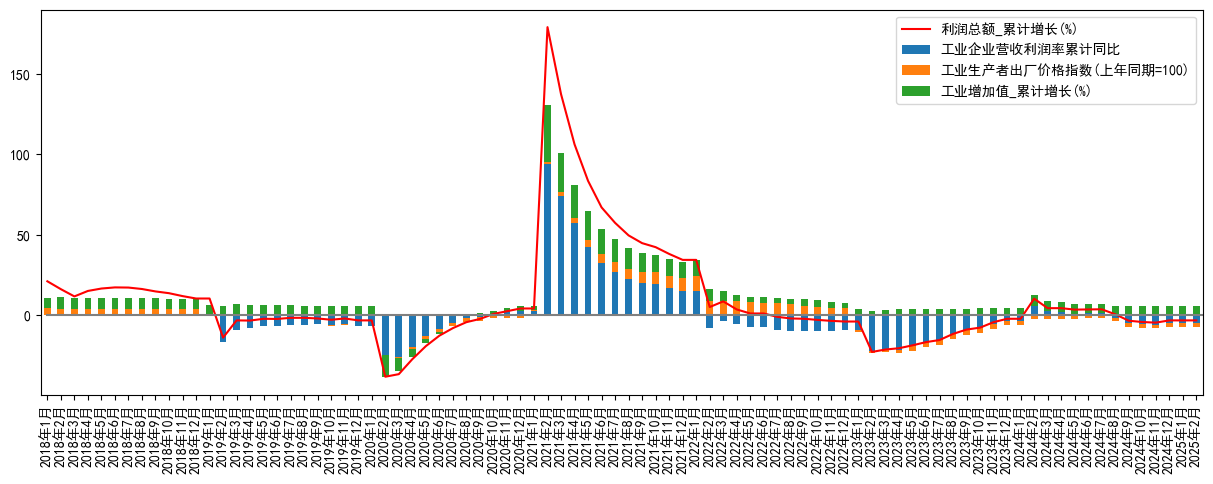

In [11]:
ax = pd.DataFrame(
    {
        "工业企业营收利润率累计同比": profitRate2018,
        "工业生产者出厂价格指数(上年同期=100)": ppiDf[
            "工业生产者出厂价格指数(上年同期=100)"
        ]
        .ffill()
        .loc["2018年1月":]
        - 100,
        "工业增加值_累计增长(%)": gyzjzDf["工业增加值_累计增长(%)"]
        .ffill()
        .loc["2018年1月":],
    }
).plot(figsize=(15, 5), kind="bar", stacked=True)
ax.plot(
    industryFinancialDf["利润总额_累计增长(%)"].ffill().loc["2018年1月":],
    label="利润总额_累计增长(%)",
    color="r",
)
ax.plot([0]*industryFinancialDf["利润总额_累计增长(%)"].size, color="gray")
plt.legend()

#### 2.2.2 从行业角度观察（待完善）

In [12]:
import hy

industryHy = hy.getIndustryHYCode()
industryHy40 = []
for (code, name) in industryHy:
    if len(code) == 2:
        industryHy40.append((code, name))

<Axes: title={'center': '2020年工业行业利润总额前20'}>

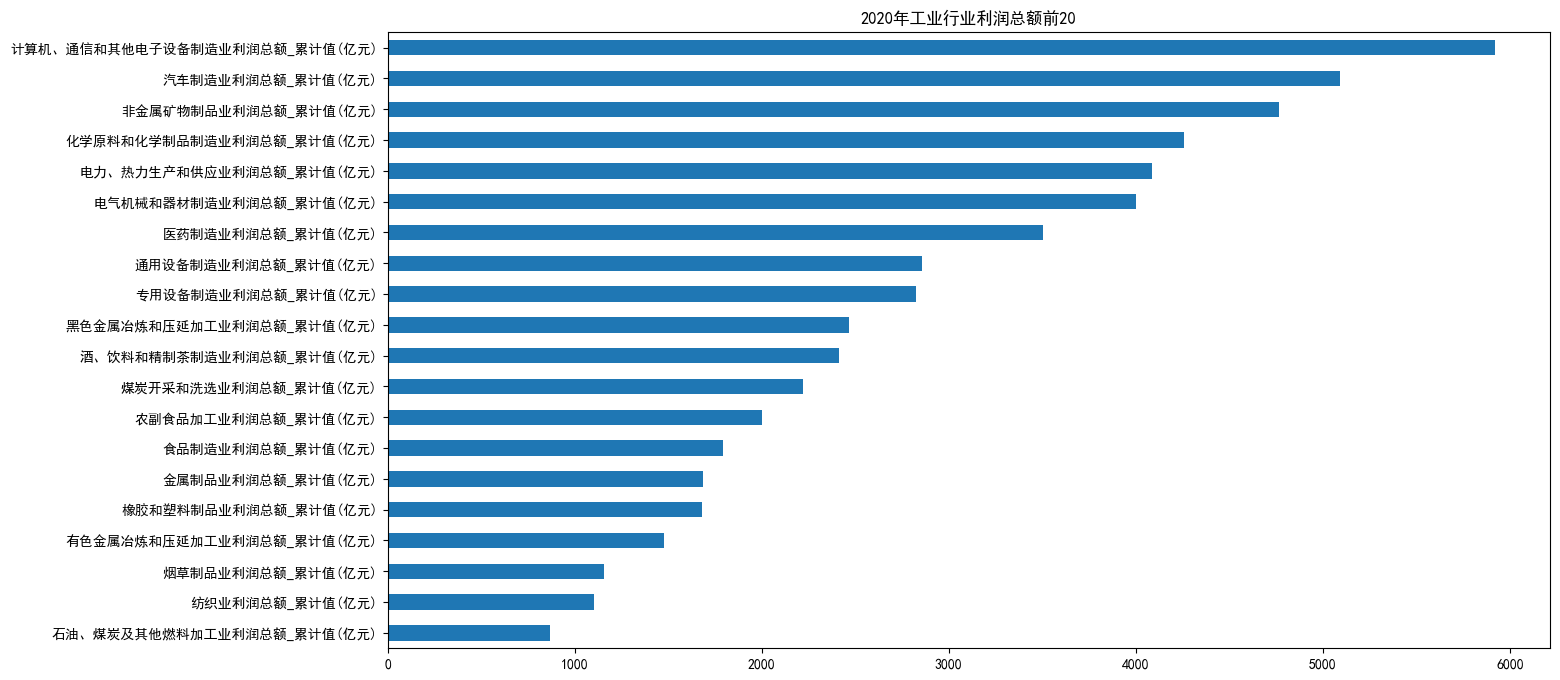

In [13]:
values = []
index = []
for code, name in industryHy40:
    values.append(
        profitByCategoriesDf.loc["2020年12月"][f"{name}利润总额_累计值(亿元)"]
    )
    index.append(f"{name}利润总额_累计值(亿元)")
s = pd.Series(values, index=index).sort_values(ascending=True)
s.iloc[-20:].plot.barh(figsize=(15, 8), title="2020年工业行业利润总额前20")

##### 2.2.2.1 上中下游企业利润总额增长率

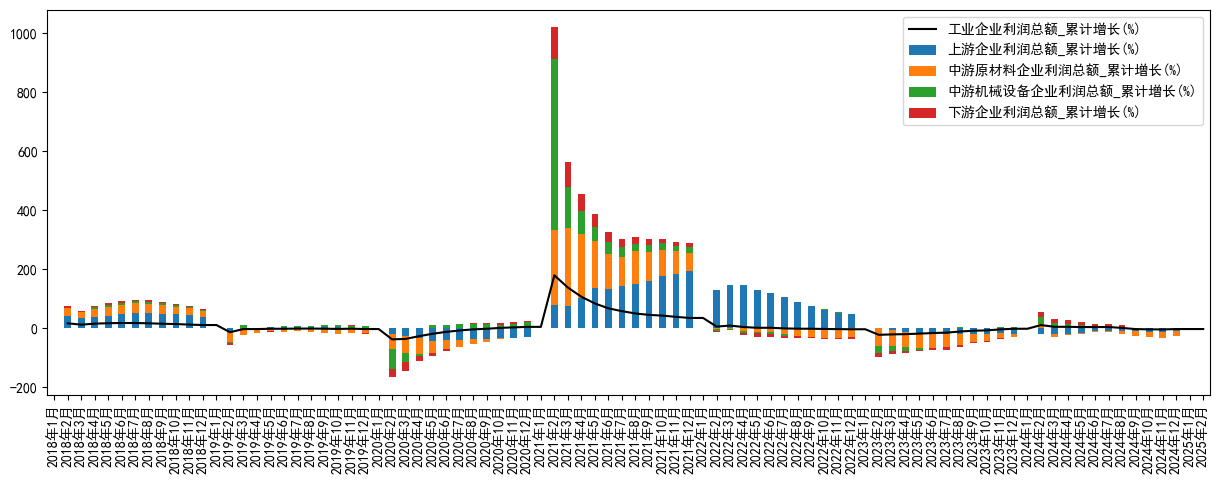

In [14]:
[upperIndustries, middleIndustries1, middleIndustries2, lowerIndustries] = (
    hy.getUpperAndLowerCooperation()
)


def getWeightedSum(list):
    xDf = profitByCategoriesDf[
        [f"{name}利润总额_累计值(亿元)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_累计值(亿元)", name) for name in list]))
    yDf = profitByCategoriesDf[
        [f"{name}利润总额_上年同期累计值(亿元)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_上年同期累计值(亿元)", name) for name in list]))
    rate = profitByCategoriesDf[
        [f"{name}利润总额_累计增长(%)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_累计增长(%)", name) for name in list]))
    total = yDf.sum(axis=1)
    weight = yDf.apply(lambda r: r / total, axis=0)
    return (weight * rate).sum(axis=1)

ax = pd.DataFrame({
    "上游企业利润总额_累计增长(%)": getWeightedSum(upperIndustries),
    "中游原材料企业利润总额_累计增长(%)": getWeightedSum(middleIndustries1),
    "中游机械设备企业利润总额_累计增长(%)": getWeightedSum(middleIndustries2),
    "下游企业利润总额_累计增长(%)": getWeightedSum(lowerIndustries),
}).plot.bar(figsize=(15,5), stacked=True)

ax.plot(profitByCategoriesDf["工业企业利润总额_累计增长(%)"].ffill(), label="工业企业利润总额_累计增长(%)", c="black")
plt.legend()


In [15]:
# (profitByCategoriesDf["工业企业利润总额_累计值(亿元)"] / profitByCategoriesDf["工业企业利润总额_上年同期累计值(亿元)"] - 1) * 100
# profitByCategoriesDf["工业企业利润总额_累计增长(%)"].ffill().plot()

# for name in profitByCategoriesDf.columns[3::3]:
#     if name[:-12] not in [name for (code, name) in industryHy40]:
#         print(name[:-12])

names = ["采矿业", "制造业", "电力、热力、燃气及水生产和供应业"]
names2 = [f"{name}利润总额_累计值(亿元)" for name in names]
profitByCategoriesDf[names2].sum(axis=1)

2018年1月         0.0
2018年2月      9689.0
2018年3月     15533.2
2018年4月     21271.8
2018年5月     27298.4
             ...   
2024年10月    58680.4
2024年11月    66674.8
2024年12月    74310.6
2025年1月         0.0
2025年2月         0.0
Length: 86, dtype: float64

#### 2.2.3 从企业类型角度观察（待完善）

#### 2.2.4 2018年数据的争议

2018年，用工业企业利润总额累计值算出来的同比，明显小于官方公布的同比。前者是负的，后者是正的。

利润表、资产负债表其他指标业出现类似情况。

官方解释是：

> 规模以上工业企业利润总额、营业收入等指标的增速均按可比口径计算。报告期数据与上年所公布的同指标数据之间有不可比因素，不能直接相比计算增速。其主要原因是：（一）根据统计制度，每年定期对规模以上工业企业调查范围进行调整。每年有部分企业达到规模标准纳入调查范围，也有部分企业因规模变小而退出调查范围，还有新建投产企业、破产、注（吊）销企业等变化。（二）加强统计执法，对统计执法检查中发现的不符合规模以上工业统计要求的企业进行了清理，对相关基数依规进行了修正。（三）加强数据质量管理，剔除跨地区、跨行业重复统计数据。

相关资料：
- https://www.stats.gov.cn/sj/zxfb/202302/t20230203_1900046.html
- https://finance.sina.com.cn/zl/stock/2018-09-26/zl-ifxeuwwr8308277.shtml

后续不使用绝对值进行分析，而用同比推算出绝对值，再进行分析。

In [16]:
# 用同比推算当期累计值
# 以第一年的数据为初值，后续每一年的数据=初值*同比
def adjustSeries(values, yoy):
    s = values.iloc[0:12].to_list()
    for idx, item in enumerate(yoy):
        if idx >= 12:
            s.append(s[idx - 12] * item)
    return pd.Series(s, index=values.index)

/tmp/ipykernel_9428/3930295857.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "工业企业利润总额累计值同比（手动计算）": industryFinancialDf["利润总额_累计值(亿元)"].pct_change(12) * 100,


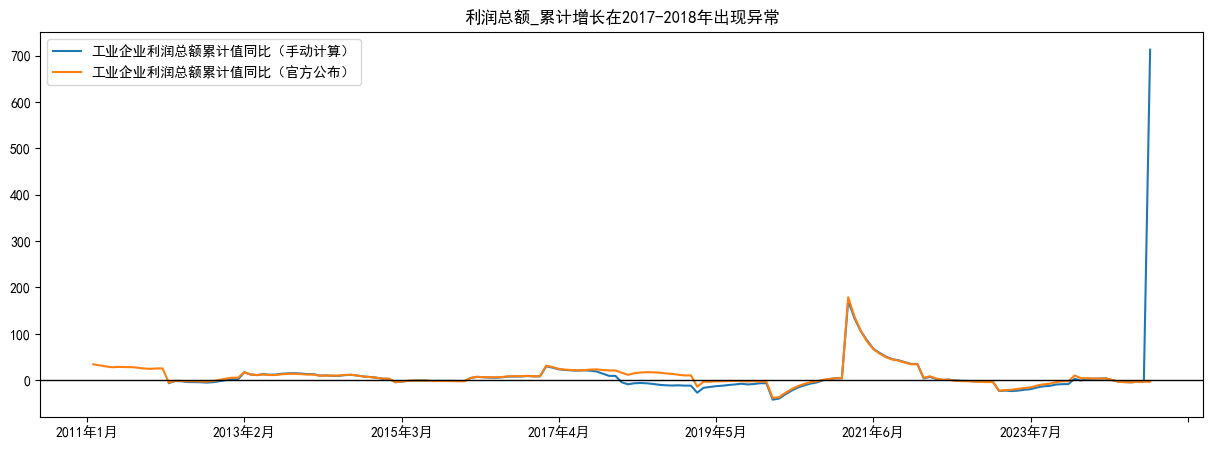

In [17]:
pd.DataFrame({
    "工业企业利润总额累计值同比（手动计算）": industryFinancialDf["利润总额_累计值(亿元)"].pct_change(12) * 100,
    "工业企业利润总额累计值同比（官方公布）": industryFinancialDf['利润总额_累计增长(%)'].ffill()
}).plot(figsize=figsize, title="利润总额_累计增长在2017-2018年出现异常")

# 零轴
plt.axhline(0, color='k', linestyle='-', linewidth=1)

国企的利润总额累计同比并没有出现显著的数据分化，而私企非常明显

/tmp/ipykernel_9428/427491526.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "私营工业企业累计值同比（手动计算）": srqyEconomicDf["私营工业企业利润总额_累计值(亿元)"].pct_change(12) * 100,
/tmp/ipykernel_9428/427491526.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "国有工业企业累计值同比（手动计算）": gyqyEconomicDf["国有工业企业利润总额_累计值(亿元)"].pct_change(12) * 100,


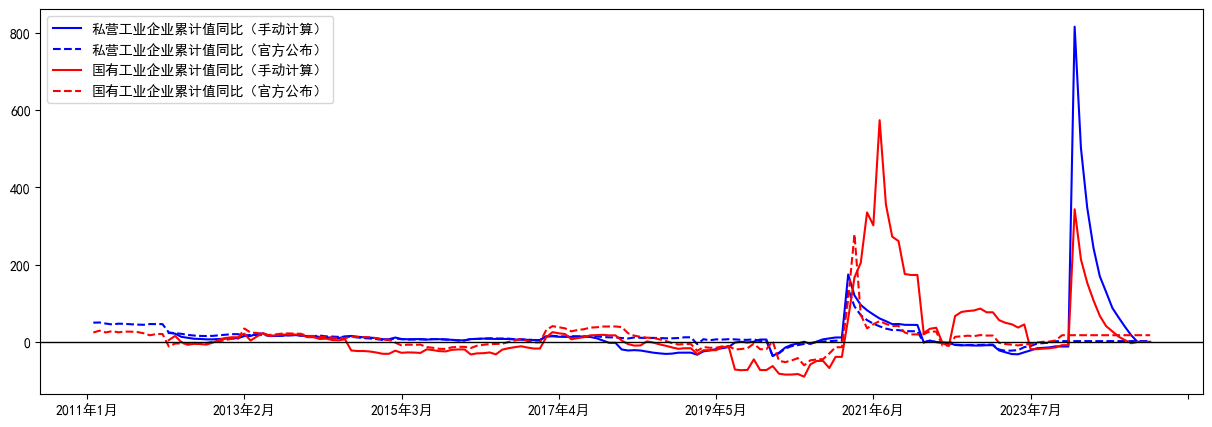

In [18]:
pd.DataFrame(
    {
        "私营工业企业累计值同比（手动计算）": srqyEconomicDf["私营工业企业利润总额_累计值(亿元)"].pct_change(12) * 100,
        "私营工业企业累计值同比（官方公布）": srqyEconomicDf["私营工业企业利润总额_累计增长(%)"].ffill(),
        "国有工业企业累计值同比（手动计算）": gyqyEconomicDf["国有工业企业利润总额_累计值(亿元)"].pct_change(12) * 100,
        "国有工业企业累计值同比（官方公布）": gyqyEconomicDf["国有工业企业利润总额_累计增长(%)"].ffill(),
    }
).plot(
    figsize=figsize,
    style={
        "私营工业企业累计值同比（手动计算）": "b",
        "私营工业企业累计值同比（官方公布）": "b--",
        "国有工业企业累计值同比（手动计算）": "r",
        "国有工业企业累计值同比（官方公布）": "r--",
    },
)

# 零轴
plt.axhline(0, color="k", linestyle="-", linewidth=1)

## 3 工业企业资产负债表数据分析

### 3.1 工业企业资产负债表结构分析

#### 3.1.1 资产负债率

资产负债率显示了企业的杠杆情况

2017年开始工业财务数据出现了比较严重的统计异常，而官方公布的资产负债率是用累计值算出来的，没有剔除异常因素。所以不要使用官方数据进行解读。

要观察真实的资产负债率，需要用官方同比先推算总资产和总负债累计值，在算出资产负债率。

<Axes: title={'center': '资产负债率'}>

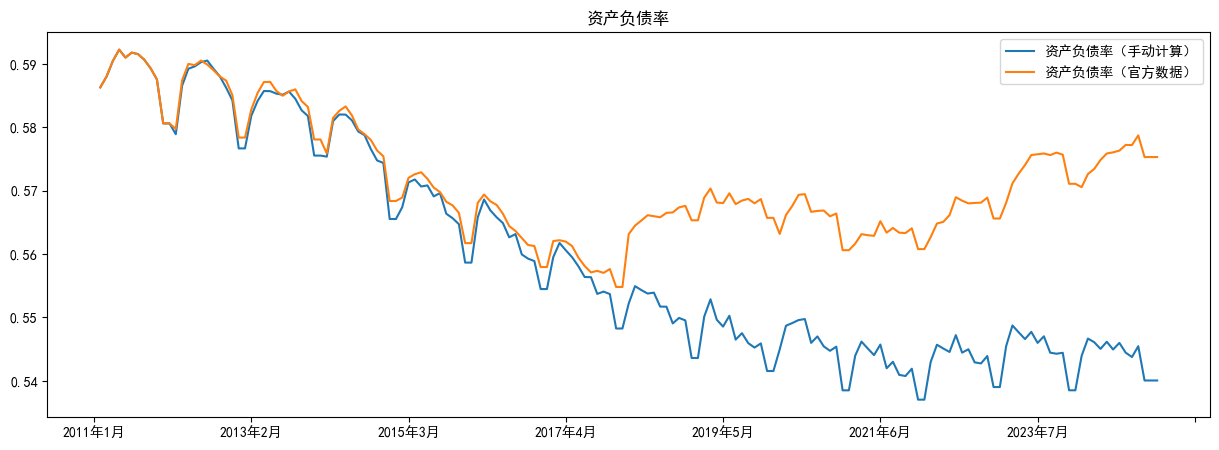

In [19]:
assets = adjustSeries(
    industryFinancialDf["资产总计_本月末(亿元)"],
    industryFinancialDf["资产总计_增减(%)"] / 100 + 1,
)
liabilities = adjustSeries(
    industryFinancialDf["负债合计_本月末(亿元)"],
    industryFinancialDf["负债合计_增减(%)"] / 100 + 1,
)

pd.DataFrame(
    {
        "资产负债率（手动计算）": (liabilities / assets),
        "资产负债率（官方数据）": (
            industryFinancialDf["负债合计_本月末(亿元)"]
            / industryFinancialDf["资产总计_本月末(亿元)"]
        ),
    }
).ffill().plot(figsize=figsize, title="资产负债率")

#### 3.1.2 产成品周转天数

产成品周转天数 = 360 * 平均产成品存货 / 营业成本 * 累计月份 / 12

/tmp/ipykernel_9428/4281859429.py:51: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "存货周转天数同比(官方数据)": chzzts.pct_change(12) * 100,
/tmp/ipykernel_9428/4281859429.py:52: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "存货周转天数同比(手动计算)": adjustedChzzts.pct_change(12) * 100


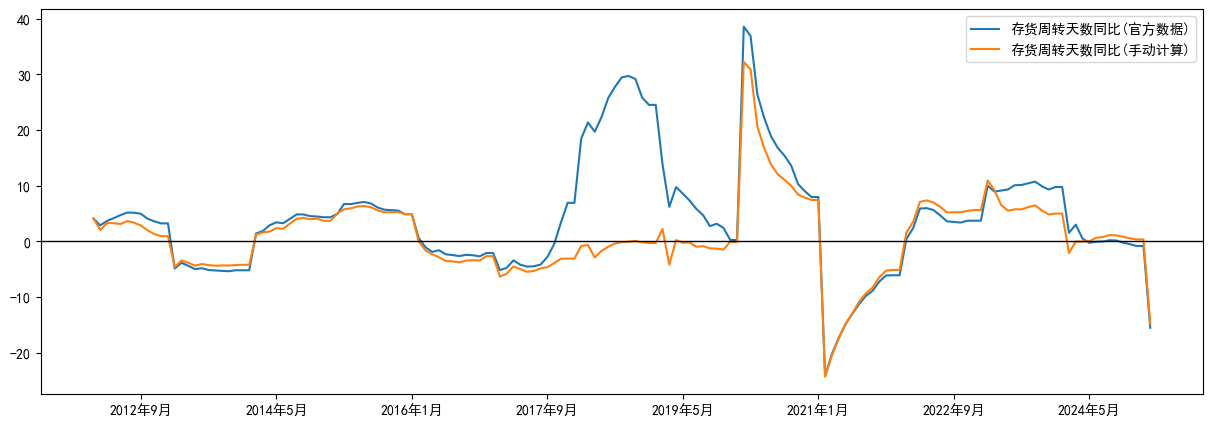

In [20]:
# industryFinancialDf[
#     [
#         "产成品存货_本月末(亿元)",
#         "产成品存货_增减(%)",
#         "营业成本_累计值(亿元)",
#         "营业成本_累计增长(%)",
#         "主营业务成本_累计值(亿元)",
#         "主营业务成本_累计增长(%)",
#     ]
# ]

totalYears = math.ceil(industryFinancialDf.shape[0] / 12)

qcpch = adjustSeries(
    industryFinancialDf["产成品存货_本月末(亿元)"],
    industryFinancialDf["产成品存货_增减(%)"] / 100 + 1
)

# 期初产成品存货=每年2月值
qcccpch = []
for i in range(totalYears):
    qcccpch.append(np.nan)    # 1月没有值
    qcccpch.extend([qcpch.loc[f'{2011+i}年2月']]*11)
qcccpch = pd.Series(qcccpch[:industryFinancialDf.shape[0]], index=industryFinancialDf.index)

# 平均产成品存货
# 因为营业成本是从年初到当前月份的累计值，所以存货的每个初值都是当年2月值（1月没有值）
chpjje = (qcccpch + qcpch) / 2

# 营业成本
yycb = pd.concat([
    industryFinancialDf["主营业务成本_累计值(亿元)"].loc[:"2018年12月"].rename({"主营业务成本_累计值(亿元)": "营业成本"}),
    industryFinancialDf["营业成本_累计值(亿元)"].loc["2019年1月":].rename({"营业成本_累计值(亿元)": "营业成本"}), 
], axis=0)
yycbRate = pd.concat([
    industryFinancialDf["主营业务成本_累计增长(%)"].loc[:"2018年12月"].rename({"主营业务成本_累计增长(%)": "营业成本_累计增长(%)"}),
    industryFinancialDf["营业成本_累计增长(%)"].loc["2019年1月":].rename({"营业成本_累计增长(%)": "营业成本_累计增长(%)"}), 
], axis=0)
# 营业成本调整后
adjustedYycb = adjustSeries(yycb, yycbRate / 100 + 1)

# 累计月数
ljys = pd.Series(list(range(1,13,1)) * math.ceil(industryFinancialDf.shape[0] / 12))[:industryFinancialDf.shape[0]]
ljys.index = industryFinancialDf.index

# 存货周转天数
chzzts = 360 * chpjje / yycb * ljys / 12
adjustedChzzts = 360 * chpjje / adjustedYycb * ljys / 12

pd.DataFrame({
    "存货周转天数同比(官方数据)": chzzts.pct_change(12) * 100,
    "存货周转天数同比(手动计算)": adjustedChzzts.pct_change(12) * 100
}).plot(figsize=figsize)
plt.axhline(0, color="k", linestyle="-", linewidth=1)

#### 3.1.3 应收账款平均回收期

应收账款平均回收期 = 360 * 平均应收款 / 营业收入 * 累计月份 / 12

应收账款回收期越短，说明赊账越少，收账迅速，企业的资金利用率高

/tmp/ipykernel_9428/1368478234.py:46: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "应收账款平均回收期(官方数据)": yszkpjhsq.pct_change(12) * 100,
/tmp/ipykernel_9428/1368478234.py:47: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  "应收账款平均回收期(手动计算)": adjustedYszkpjhsq.pct_change(12) * 100,


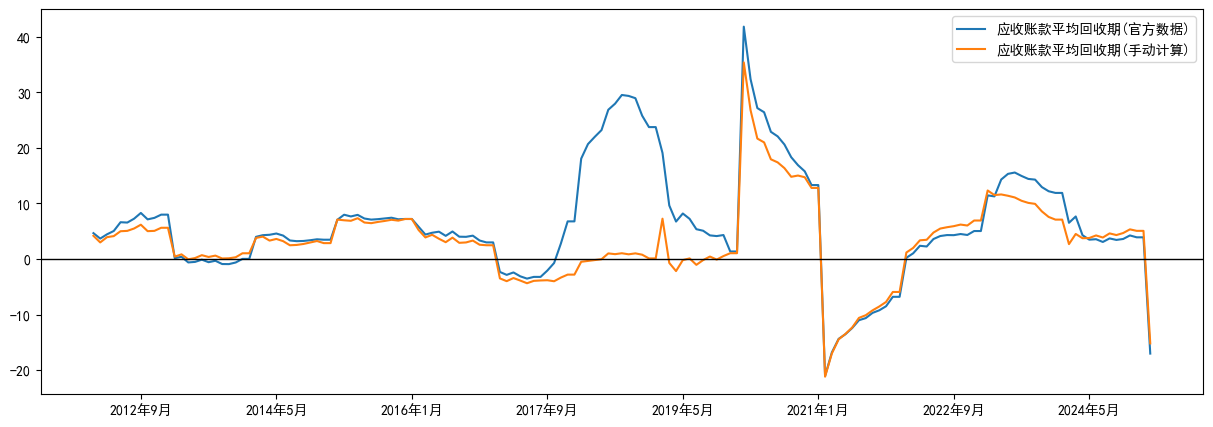

In [21]:
# 2019年应收账款没有数据，应收票据及应收账款有数据
# industryFinancialDf.loc["2019年1月":"2019年12月", "应收账款_本月末(亿元)"] = (
#     industryFinancialDf.loc["2019年1月":"2019年12月", "应收票据及应收账款_本月末(亿元)"]
# )
industryFinancialDf.loc["2019年1月":"2019年12月", "应收账款_增减(%)"] = (
    industryFinancialDf.loc["2019年1月":"2019年12月", "应收票据及应收账款_增减(%)"]
)

ysk = adjustSeries(
    industryFinancialDf["应收账款_本月末(亿元)"],
    industryFinancialDf["应收账款_增减(%)"] / 100 + 1,
)

# 期初值=每年2月值
qcysk = []
for i in range(totalYears):
    qcysk.append(np.nan)  # 1月没有值
    qcysk.extend(
        [ysk.loc[f"{2011+i}年2月"]] * 11
    )
qcysk = pd.Series(
    qcccpch[: industryFinancialDf.shape[0]], index=industryFinancialDf.index
)

# 平均应收款
pjysk = (qcysk + ysk) / 2

# 营业收入
yysr = pd.concat([
    industryFinancialDf["主营业务收入_累计值(亿元)"].loc[:"2018年12月"].rename({"主营业务收入_累计值(亿元)": "营业收入"}),
    industryFinancialDf["营业收入_累计值(亿元)"].loc["2019年1月":].rename({"营业收入_累计值(亿元)": "营业收入"}), 
], axis=0)
yysrRate = pd.concat([
    industryFinancialDf["主营业务收入_累计增长(%)"].loc[:"2018年12月"].rename({"主营业务收入_累计增长(%)": "营业收入_累计增长(%)"}),
    industryFinancialDf["营业收入_累计增长(%)"].loc["2019年1月":].rename({"营业收入_累计增长(%)": "营业收入_累计增长(%)"}), 
], axis=0)
# 营业成本调整后
adjustedYysr = adjustSeries(yysr, yysrRate / 100 + 1)

# 应收账款平均回收期
yszkpjhsq = 360 * pjysk / yysr * ljys / 12
adjustedYszkpjhsq = 360 * pjysk / adjustedYysr * ljys / 12

pd.DataFrame(
    {
        "应收账款平均回收期(官方数据)": yszkpjhsq.pct_change(12) * 100,
        "应收账款平均回收期(手动计算)": adjustedYszkpjhsq.pct_change(12) * 100,
    }
).plot(figsize=figsize)
plt.axhline(0, color="k", linestyle="-", linewidth=1)

### 3.2 工业企业产成品存货数据分析

随着经济增长和企业规模扩张，产成品存货的绝对值也会不断增长，因此我们一般观察产成品存货的同比。

产成品存货使用金额来度量的，因此包含价格因素。所以在分析时，也需要关注价格因素，比如ppi。

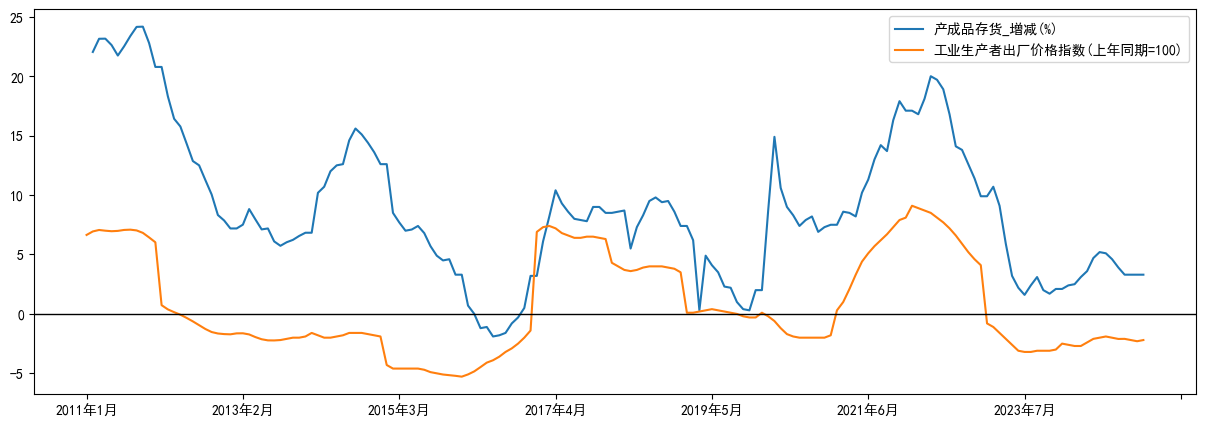

In [22]:
pd.DataFrame({
    "产成品存货_增减(%)": industryFinancialDf["产成品存货_增减(%)"],
    "工业生产者出厂价格指数(上年同期=100)": ppiDf["工业生产者出厂价格指数(上年同期=100)"] - 100
}).ffill().plot(figsize=figsize)

plt.axhline(0, color="k", linestyle="-", linewidth=1)

存在很多中经济周期：技术周期、产业周期、房地产周期、金融周期、资本开支周期、库存周期等等

#### 3.2.1 库存周期

企业库存是供需力量对比的结果。相对于需求变化而言，供给的变化往往存在时滞，所以库存水平会出现周期性波动。

库存周期是经济周期的响应结果，而不是成因。

库存周期由`工业企业产成品存货同比`和`工业企业营业收入同比`度量。

工业企业产成品存货同比的走势，决定了经济是处于补库存还是去库存的阶段；而工业企业营业收入同比的走势，决定了库存行为是主动的还是被动的。

一个完整的库存周期一般包括4个阶段：

1. 主动补库存：产成品存货同比和营业收入同比都上升：经济繁荣，需求旺盛，企业更大力度加速生产，库存水平上升
2. 被动补库存：营业收入同比下降，产成品存货同比上升：经济走过繁荣顶点，开始衰退，需求下滑，企业生产随之放缓，但需求下滑更快，库存水平上升
3. 主动去库存：营业收入同比下降，产成品存货同比下降：经济由衰退进入萧条期，需求低迷，企业生产也大幅收缩，库存水平下降
4. 被动去库存：营业收入同比上升，产成品存货同比下降：经济由萧条迈向复苏，需求回暖，企业生产开始重启但是没有跟上需求，库存水平下降

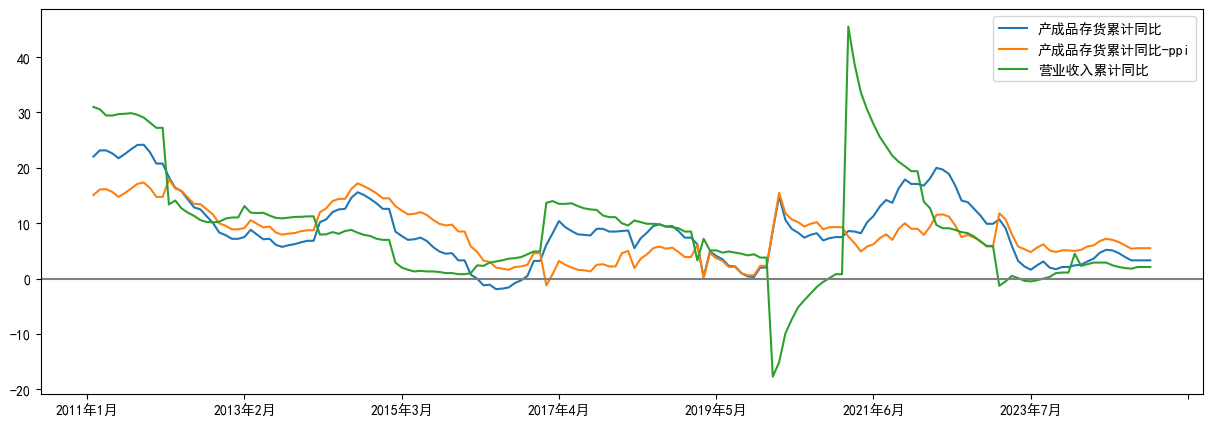

In [23]:
pd.DataFrame({
    "产成品存货累计同比": industryFinancialDf["产成品存货_增减(%)"],
    "产成品存货累计同比-ppi": industryFinancialDf["产成品存货_增减(%)"] - ppiDf['工业生产者出厂价格指数(上年同期=100)'] + 100,
    "营业收入累计同比": yysrRate
}).ffill().plot(figsize=figsize)
plt.axhline(0, color="gray")

#### 3.2.3 中国历史库存周期分析

1. 经验底部
2. 持续时长（最长、最短、平均）
3. 周期强度
4. 阶段占比

#### 3.2.4 行业库存周期的分化
